## apprentissage non supervisé

* on va prendre un exemple **concret** et réaliste pour bien voir l’utilité de **K-Means**.

---

** Exemple concret : **Segmentation de clients en marketing**

## 1. Contexte

Une entreprise veut **regrouper ses clients** pour mieux cibler ses campagnes publicitaires.
On a collecté ces variables pour chaque client :

* `Age` (en années) → numérique continu
* `Revenu annuel` (en \$) → numérique continu
* `Score de dépense` (0–100, basé sur le comportement d’achat)

Ces 3 variables sont idéales pour un **clustering K-Means**.

---

## 2. Jeu de données d’exemple

Imaginons qu’on ait ce petit tableau (extrait simplifié) :

| Client | Âge | Revenu annuel (\$) | Score de dépense |
| ------ | --: | -----------------: | ---------------: |
| 1      |  19 |             15,000 |               39 |
| 2      |  35 |             40,000 |               81 |
| 3      |  26 |             17,000 |                6 |
| 4      |  40 |             80,000 |               77 |
| 5      |  65 |            120,000 |               20 |
| 6      |  29 |             50,000 |               99 |
| 7      |  54 |            100,000 |               24 |
| 8      |  23 |             30,000 |               70 |
| 9      |  31 |             60,000 |               88 |
| 10     |  45 |            150,000 |               15 |

---

## 3. Objectif

Découvrir automatiquement des **groupes de clients** :

* jeunes à faible revenu,
* jeunes gros dépensiers,
* clients âgés et riches mais peu dépensiers,
* etc.

---



In [122]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ========================
# 1. Créer le DataFrame
# ========================
data= pd.read_excel("d:\ML\ML_project\individus_kmeans.xlsx")

df = pd.DataFrame(data)

df


<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
C:\Users\hermanhk\AppData\Local\Temp\ipykernel_14248\4023074501.py:9: SyntaxWarning: invalid escape sequence '\M'
  data= pd.read_excel("d:\ML\ML_project\individus_kmeans.xlsx")


,Age,Revenu,Score
0,56,124752,32
1,69,58984,96
2,46,50774,88
3,32,12568,52
4,60,130151,62
...,...,...,...
95,42,13748,54
96,62,23545,33
97,58,137659,24
98,46,175838,75


In [123]:
# ========================
# 2. Normaliser les données
# ========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled


array([[ 0.85300339,  0.26774982, -0.54520252],
       [ 1.72960766, -0.93457997,  1.52069216],
       [ 0.17869241, -1.0846701 ,  1.26245532],
       [-0.76534296, -1.78312849,  0.10038957],
       [ 1.12272778,  0.36645099,  0.42318561],
       [-1.23736065,  0.61537026,  0.2940672 ],
       [-0.36075637,  0.44367154,  0.10038957],
       [ 0.85300339,  1.44708163, -1.1907946 ],
       [-0.49561857,  0.66222543, -0.31924529],
       [-0.22589418, -1.10788745, -1.51359065],
       [-1.03506735,  1.17229421, -1.48131104],
       [-1.03506735, -1.5743917 ,  0.22950799],
       [-0.15846308, -0.69922548,  1.03649809],
       [ 0.6507101 ,  0.53392671,  0.3263468 ],
       [ 0.92043449, -1.59852312, -1.51359065],
       [-0.15846308, -1.12331693, -1.51359065],
       [-1.57451614,  0.63120193,  1.39157374],
       [-0.29332528, -1.3391469 ,  0.16494878],
       [-1.64194724, -0.65083467,  1.23017572],
       [-0.15846308,  0.08010974,  1.52069216],
       [ 1.19015888,  1.52132232,  1.552

    Age  Revenu  Score  Cluster
0    56  124752     32        1
1    69   58984     96        0
2    46   50774     88        2
3    32   12568     52        2
4    60  130151     62        0
..  ...     ...    ...      ...
95   42   13748     54        2
96   62   23545     33        1
97   58  137659     24        1
98   46  175838     75        0
99   32   83530     72        2

[100 rows x 4 columns]


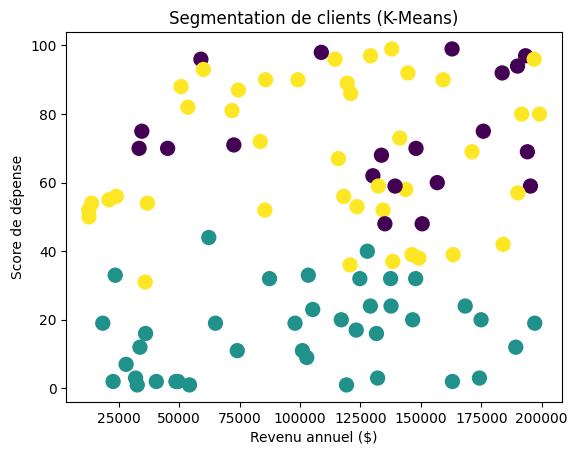

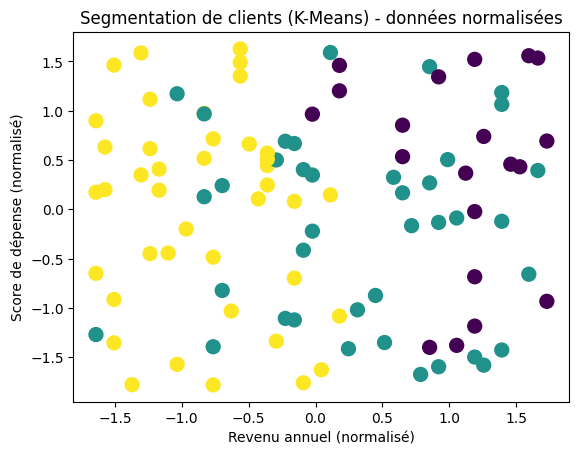

In [124]:



# ========================
# 3. Appliquer K-Means
# ========================
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters  # ajouter les étiquettes

print(df)

# ========================
# 4. Visualisation
# ========================
plt.scatter(df["Revenu"], df["Score"], c=df["Cluster"], cmap="viridis", s=100)
plt.xlabel("Revenu annuel ($)")
plt.ylabel("Score de dépense")
plt.title("Segmentation de clients (K-Means)")
plt.show()

# Vue 2 : données normalisées
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df["Cluster"], cmap="viridis", s=100)
plt.xlabel("Revenu annuel (normalisé)")
plt.ylabel("Score de dépense (normalisé)")
plt.title("Segmentation de clients (K-Means) - données normalisées")
plt.show()

#INTERPRETATION

* **Axe X = Revenu annuel (\$)**
* **Axe Y = Score de dépense (comportement d’achat, 0 → dépense très faible, 100 → dépense très élevée)**
* Les **couleurs** représentent les différents **clusters (groupes de clients)** identifiés par K-Means.

### Interprétation des clusters

Imaginons que les couleurs correspondent aux 3 groupes :

1. **Cluster 1 (en bas à gauche, revenus faibles / scores faibles)**
   👉 Ce sont des clients avec **peu de moyens financiers** et qui **dépensent peu**.
   ➡️ Importance : ce groupe n’est pas très rentable, pas la peine de cibler avec des produits de luxe.

2. **Cluster 2 (en haut à gauche, revenus faibles / scores élevés)**
   👉 Ici on a des clients avec **revenus modestes mais qui dépensent beaucoup** (fidèles ou dépensiers).
   ➡️ Importance : excellent groupe pour des campagnes de **fidélisation** et des **offres promotionnelles**.

3. **Cluster 3 (à droite, revenus élevés mais scores variables)**
   👉 Clients avec **revenus élevés**, certains dépensent beaucoup, d’autres très peu.
   ➡️ Importance : c’est là qu’il faut **cibler les “gros dépensiers” riches** (marketing premium, offres exclusives). Ceux qui dépensent peu malgré leur revenu peuvent être à motiver.

---

👉 En résumé :

* Le K-Means permet ici de **segmenter la clientèle** pour adapter la stratégie marketing.
* L’entreprise peut personnaliser ses **campagnes publicitaires** et **politiques de prix** en fonction des groupes.

---


##Des variantes de K-Means (K-Means++, Mini-Batch K-Means, Kernel K-Means)

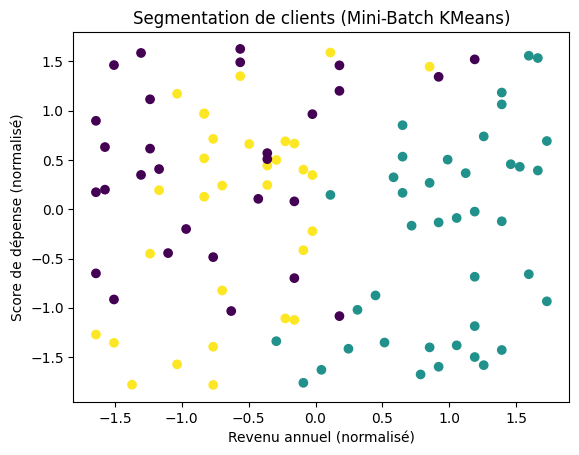

In [125]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

# Mini-Batch KMeans
mbk = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=20)
clusters_mbk = mbk.fit_predict(X_scaled)

# Visualisation
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_mbk, cmap="viridis")
plt.title("Segmentation de clients (Mini-Batch KMeans)")
plt.xlabel("Revenu annuel (normalisé)")
plt.ylabel("Score de dépense (normalisé)")
plt.show()


Mini-Batch K-Means

Fonctionne comme K-Means, mais au lieu d’utiliser tout le dataset à chaque itération, il utilise de petits lots (mini-batches).

Plus rapide sur les grands datasets.

Résultats très proches de K-Means classique.

Qu’est-ce que K-Means++ ?

C’est une amélioration de l’initialisation des centres (centroïdes) dans K-Means.

Problème de K-Means classique : il choisit les centroïdes au hasard, ce qui peut donner de mauvais résultats (mauvais regroupements ou convergence lente).

Solution de K-Means++ :

Choisit le premier centroïde au hasard.

Les suivants sont choisis avec une probabilité proportionnelle à leur distance aux centroïdes déjà choisis → donc on évite d’avoir deux centres trop proches.

👉 Résultat :

Convergence plus rapide.

Meilleurs clusters en moyenne.

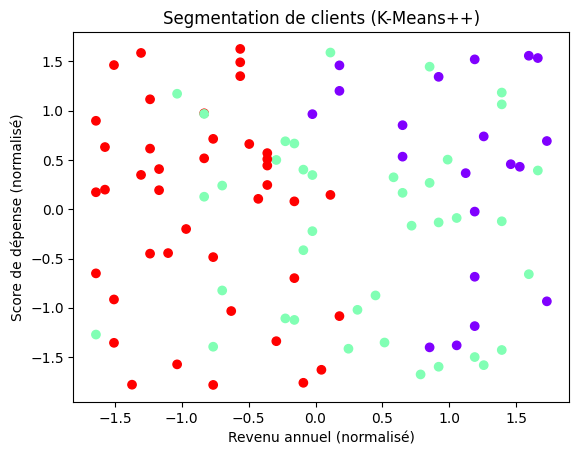

In [126]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# K-Means++ (explicite)
kmeans_pp = KMeans(n_clusters=3, init="k-means++", random_state=42)
clusters_pp = kmeans_pp.fit_predict(X_scaled)

# Visualisation
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_pp, cmap="rainbow")
plt.title("Segmentation de clients (K-Means++)")
plt.xlabel("Revenu annuel (normalisé)")
plt.ylabel("Score de dépense (normalisé)")
plt.show()


### ANALYSE COMPARATIVE 
----------------------------------------------------------------------------
trois méthodes différentes de **segmentation de clients** appliquées sur les mêmes données normalisées (Revenu annuel & Score de dépense). Comparons-les :

---

### **1. K-Means (classique)**

* **Observation :**

  * On voit trois clusters relativement bien séparés, mais avec un chevauchement non négligeable (surtout au centre et à gauche).
  * La séparation est correcte mais pas optimale, certains clients proches en termes de revenus et de dépenses sont classés dans des clusters différents.
* **Forces :**

  * Méthode simple et efficace.
  * Convient bien quand les données sont bien réparties et sphériques.
* **Limites :**

  * Sensible à l’initialisation des centroïdes.
  * Peut coincer dans un optimum local.

---

### **2. Mini-Batch KMeans**

* **Observation :**

  * Les clusters sont moins nets que dans le K-Means classique.
  * On remarque une certaine "dispersion" des points : certains clusters semblent mélangés.
  * La séparation entre groupes n’est pas toujours très cohérente (certains points proches sont classés différemment).
* **Forces :**

  * Plus rapide et scalable (utile pour de très grands jeux de données).
  * Moins coûteux en mémoire.
* **Limites :**

  * Moins précis que le K-Means classique.
  * Peut donner des résultats instables, surtout avec de petits datasets.

---

### **3. K-Means++**

* **Observation :**

  * La segmentation est plus nette que dans K-Means classique et Mini-Batch.
  * Les clusters semblent mieux équilibrés, avec moins de chevauchements.
  * L’algorithme choisit de meilleurs centroïdes initiaux, ce qui améliore la qualité finale des clusters.
* **Forces :**

  * Réduit le problème d’initialisation hasardeuse.
  * Donne généralement des résultats plus stables et de meilleure qualité que K-Means simple.
* **Limites :**

  * Un peu plus lent à l’initialisation que le K-Means classique.

---

### **Résumé comparatif**

| Méthode        | Précision  | Vitesse     | Adaptée aux grands jeux de données | Commentaire                                                               |
| -------------- | ---------- | ----------- | ---------------------------------- | ------------------------------------------------------------------------- |
| **K-Means**    | Bonne      | Moyenne     | Moyen                              | Simple mais sensible à l’initialisation.                                  |
| **Mini-Batch** | Moyenne    | Très rapide | Excellente                         | Sacrifie un peu la précision pour la vitesse.                             |
| **K-Means++**  | Excellente | Moyenne     | Moyen                              | Meilleure qualité des clusters grâce au choix intelligent des centroïdes. |

---

**Conclusion :**

* Si tu travailles avec **peu de données**, le **K-Means++** est préférable pour une segmentation plus fiable.
* Si tu veux de la **vitesse sur un grand dataset**, le **Mini-Batch KMeans** est plus adapté.
* Le **K-Means classique** reste une bonne base, mais moins robuste que K-Means++.




### DBSCAN
---------------------------------------
Ne nécessite pas de fixer K à l’avance.

Capable de détecter les formes complexes (pas seulement sphériques comme K-Means).

Gère bien le bruit / outliers.

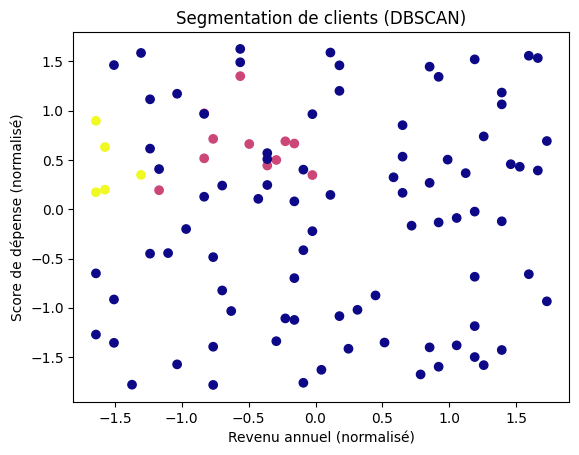

In [127]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_db = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_db, cmap="plasma")
plt.title("Segmentation de clients (DBSCAN)")
plt.xlabel("Revenu annuel (normalisé)")
plt.ylabel("Score de dépense (normalisé)")
plt.show()


Interprétation du graphique DBSCAN

Points colorés :

Jaunes et rouges → deux petits clusters identifiés.

Bleu foncé → la majorité des points sont considérés comme du bruit (outliers) ou comme faisant partie d’un grand groupe non structuré.

Observation :

Contrairement à K-Means, DBSCAN ne force pas tous les points à appartenir à un cluster.

On voit que DBSCAN n’a trouvé que 2 clusters réels (jaune & rouge) et a classé le reste en bruit (bleu foncé).

Cela signifie que la structure naturelle de tes données ne présente pas des groupes bien séparés et denses, sauf pour quelques sous-groupes.

Forces de DBSCAN

✅ Capte les formes non sphériques de clusters (contrairement à K-Means qui impose une forme circulaire).
✅ Identifie les outliers (points atypiques).
✅ Pas besoin de fixer le nombre de clusters à l’avance.

Limites constatées ici

❌ Avec ton jeu de données (revenu + score normalisés), DBSCAN n’a trouvé que peu de clusters significatifs, ce qui peut indiquer :

Soit que les paramètres eps (rayon) et min_samples (densité minimale) ne sont pas bien ajustés.

Soit que tes données n’ont pas une structure de densité claire → DBSCAN n’est pas optimal ici.

Comparaison rapide avec K-Means

K-Means a réussi à créer 3-4 clusters bien séparés (même si imparfaits).

DBSCAN est beaucoup plus strict : il ne trouve que les zones où les points sont très denses → d’où les petits groupes rouge/jaune.

La majorité des clients (en bleu) sont vus comme “isolés” → donc pas vraiment segmentés.

👉 Conclusion :

DBSCAN est excellent si tu veux détecter des groupes atypiques ou marginaux dans tes clients (par exemple des “niches” de clients très particuliers).

Mais pour une segmentation marketing générale (où tous les clients doivent être regroupés), K-Means++ est plus adapté.

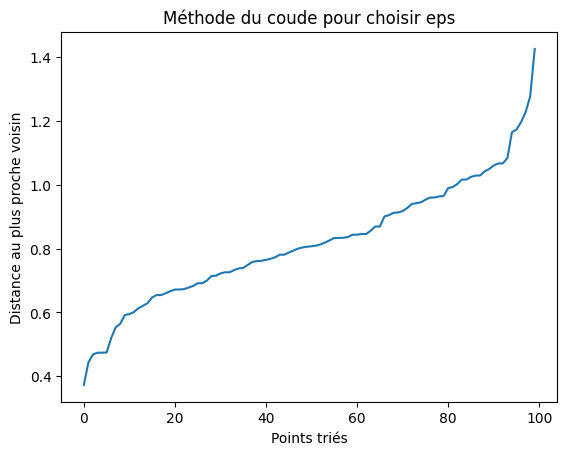

In [128]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Choisir le nombre de voisins = min_samples
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Trier les distances
distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.title("Méthode du coude pour choisir eps")
plt.xlabel("Points triés")
plt.ylabel("Distance au plus proche voisin")
plt.show()


## 4. Relancer DBSCAN avec de meilleurs paramètres

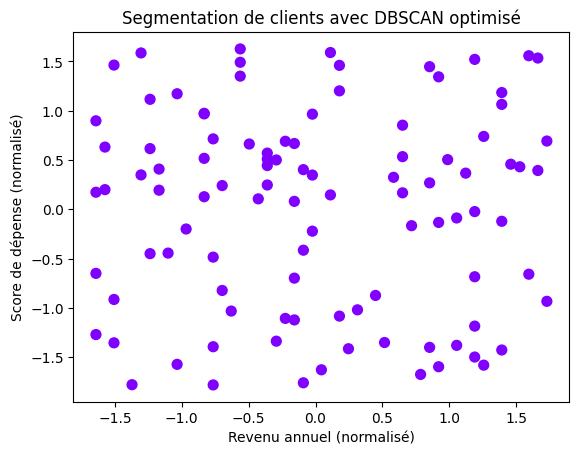

In [129]:
from sklearn.cluster import DBSCAN

# Exemple : eps choisi après la courbe, min_samples = 5
dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap="rainbow", s=50)
plt.xlabel("Revenu annuel (normalisé)")
plt.ylabel("Score de dépense (normalisé)")
plt.title("Segmentation de clients avec DBSCAN optimisé")
plt.show()




Ici, le **DBSCAN optimisé** affiche un seul nuage de points **violets**, ce qui veut dire :

1. **DBSCAN n’a trouvé qu’un seul cluster**
   → Tous les points appartiennent au même groupe, donc il n’a pas réussi à distinguer de segments de clients différents.

2. **Ca peut venir des paramètres `eps` et `min_samples`** :

   * Si `eps` est trop grand → DBSCAN relie presque tout et fait **1 seul cluster**.
   * Si `eps` est trop petit → il classe beaucoup de points en **bruit (-1)**.

3. **Ton dataset (revenu annuel vs score de dépense, normalisés)** :

   * En vrai, on s’attend à **plusieurs segments de clients** (ex. gros revenu + gros dépense, petit revenu + faible dépense, etc.).
   * Le fait d’avoir **un seul cluster violet** montre que les paramètres actuels ne reflètent pas la structure naturelle.

---

📌 **Conclusion de l’interprétation** :
Ton résultat indique que **DBSCAN a fusionné tous les clients dans un seul groupe**, ce qui n’est pas utile pour une segmentation marketing. Tu devrais ajuster `eps` avec la **courbe k-distance** pour trouver un bon seuil, et tester aussi d’autres `min_samples` (par exemple 3, 4, 5, 10).

